In [92]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task1.ipynb")

# Homework 3 - Task 1: Regularized Regression
## Comparing Ridge and Lasso for Predicting Building Heating Load

---

### Background

Regression problems can often contain dozens of predictors that are correlated with each other, redundant, or simply noise. Standard linear regression struggles in these settings because it spreads coefficient estimates across correlated features, inflates variance, and can overfit.

**Regularization** addresses this by adding a penalty to the least-squares objective. Both Ridge and Lasso start from the standard least squares criterion:

$$\text{RSS} = \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2$$

and adds a penalty term that shrinks coefficient estimates toward zero, trading a small increase in bias for a potentially large reduction in variance.

---

### Dataset

Buildings account for a significant portion of global energy consumption. This dataset contains energy performance data for **768 building configurations** simulated with Ecotect software, varying across eight architectural variables:

| Predictor | Description |
|---|---|
| Relative Compactness | How compact the building's shape is |
| Surface Area | Total external surface area |
| Wall Area | Total area of the walls |
| Roof Area | Area of the roof |
| Overall Height | Height of the building |
| Orientation | Direction the building faces (encoded numerically) |
| Glazing Area | Percentage of facade that is glass |
| Glazing Area Distribution | Distribution of glazing (even vs. concentrated) |

#### Response Variable

| Column | Description |
|---|---|
| Heating Load (Y1) | Continuous target — heating energy requirements |

*Cooling Load (Y2) is also in the dataset but is not used in this assignment.*


More information on the dataset used in this lab can be found [here](https://archive.ics.uci.edu/dataset/242/energy+efficiency).

### Setup: Load libraries and read in data

Run the cell below to import all required packages and fetch the energy efficiency dataset from the UC Irvine Machine Learning Repository.

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from ucimlrepo import fetch_ucirepo 
from sklearn.decomposition import PCA


### Step 1: Load the data

The cell below fetches the energy efficiency dataset from the UC Irvine Machine Learning Repository and converts it's contents to a dataframe. 

In [94]:
energy_efficiency = fetch_ucirepo(id=242)

feature_names = [
    "Relative Compactness", "Surface Area", "Wall Area", "Roof Area",
    "Overall Height", "Orientation", "Glazing Area", "Glazing Area Distribution"
]

df = energy_efficiency.data.features.copy()
df.columns = feature_names
df["Heating Load"] = energy_efficiency.data.targets.iloc[:, 0].values

df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


### Step 2: Preprocess the data

Split the data into training and test sets using a 70/30 split and a `random_state` of 42. Then scale the data using `StandardScaler`. Name your scaled data `X_train_scaled` and `X_test_scaled`. 

In [95]:
# Separate predictors from response
X = df[feature_names]
y = df["Heating Load"]

# Provide  70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.3, random_state=42
)

# Scale data
scaler = StandardScaler()

# Transform only X
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(X_train_scaled.shape[0])
print(X_test_scaled.shape[0])


537
231


In [96]:
grader.check("q1")

q1 results: All test cases passed!

### Step 3: Fit OLS Regression

Start with a plain OLS model as a baseline. Fit it on the training data. Calculate the MSE in a variable called `mse_ols` and inspect the coefficients.

In [97]:
# Fit OLS model
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

# Calculate MSE for OLS
y_pred_ols = ols.predict(X_test_scaled)
mse_ols = mean_squared_error(y_test, y_pred_ols)

print(mse_ols)


8.853262859505392


In [98]:
grader.check("q2")

q2 results:
    q2 - 1 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(mse_ols, 8.8395, atol=0.01)
        Expecting nothing
        **********************************************************************
        Line 1, in q2 0
        Failed example:
            assert np.isclose(mse_ols, 8.8395, atol=0.01)
        Exception raised:
            Traceback (most recent call last):
              File "c:\Users\joshu\.conda\envs\eds232-env\lib\doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q2 0[0]>", line 1, in <module>
                assert np.isclose(mse_ols, 8.8395, atol=0.01)
            AssertionError

### Step 4: Fit Ridge with Cross-Validation

So far you've selected hyperparameters by manually looping over values and using `cross_val_score` to evaluate each one. `RidgeCV` does exactly the same thing. It's a convenience wrapper that handles that loop for you internally. Ft a `RidgeCV` model using the following lambda values: `np.logspace(-4,4, 100)` and`cv` of 10. Create a table comparing the coefficients for both OLS and Ridge. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Ridge Coefficient`. 

```python
# What you've done before:
for lambda in lambdas:
    ridge = Ridge(alpha=lambda)
    scores = cross_val_score(ridge, X_train, y_train, cv=10, scoring='neg_mean_squared_error')
    ...

# What RidgeCV does under the hood (same idea, built in):
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
ridge_cv.alpha_   # Lambda with the best CV score
```

After calling `.fit()`, `ridge_cv` behaves like a regular fitted `Ridge` model. You can call `.predict()`, inspect `.coef_`, and so on. The best lambda is stored in `ridge_cv.alpha_`.

In [99]:
# Define lambda values given
lambdas = np.logspace(-4, 4, 100)

# Fit Ridge model
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')

ridge_cv.fit(X_train_scaled, y_train)

# Compare coeffs
coefficient_table = pd.DataFrame(
    data={
        "Feature":feature_names,
        "OLS Coffiencient":mse_ols,
        "Ridge Coefficient": ridge_cv.coef_
    }
)
print(coefficient_table)

                     Feature  OLS Coffiencient  Ridge Coefficient
0       Relative Compactness          8.853263          -6.352418
1               Surface Area          8.853263          -3.474392
2                  Wall Area          8.853263           0.816587
3                  Roof Area          8.853263          -3.797180
4             Overall Height          8.853263           7.306373
5                Orientation          8.853263          -0.025299
6               Glazing Area          8.853263           2.670852
7  Glazing Area Distribution          8.853263           0.356417


In [100]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: Is the penalty term doing its job?  How can you tell?**

Yes, the Ridge penalty term is shrinking the coefficients towards zero. Based on the table above, every Ridge coefficient is much smaller in magnitidude than the corresponding OLS coefficients. The OLS coefficients are all the same coefficient, which indicates multicollinearity. Ridge redistributes the influence of each feature accordingly.

<!-- END QUESTION -->

### Step 5: Evaluate Ridge Model

Use the cross-validated ridge model from Step 4 to predict on the test set and compute MSE.

In [101]:
y_test_pred_rcv = ridge_cv.predict(X_test_scaled)
mse_rcv = mean_squared_error(y_test, y_test_pred_rcv)

print(mse_rcv)


8.843961469551758


In [102]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 6: Ridge Coefficient Path

Now, create a plot looking at the coefficient values against lambda (similar to the one introduced in the [Regularization Notes)](https://meds-eds-232.github.io/EDS-232-course-website/notes/6_linear_model_selection_and_regularization/6_linear_model_selection_and_regularization-NOTES.html). Start by fitting a Ridge model for the values of lambda defined in Step 4. Then create a plot of the ridge regression coefficient profiles. Each feature should be plotted, with their coefficient value on the y axis and lambda values on the x axis. 

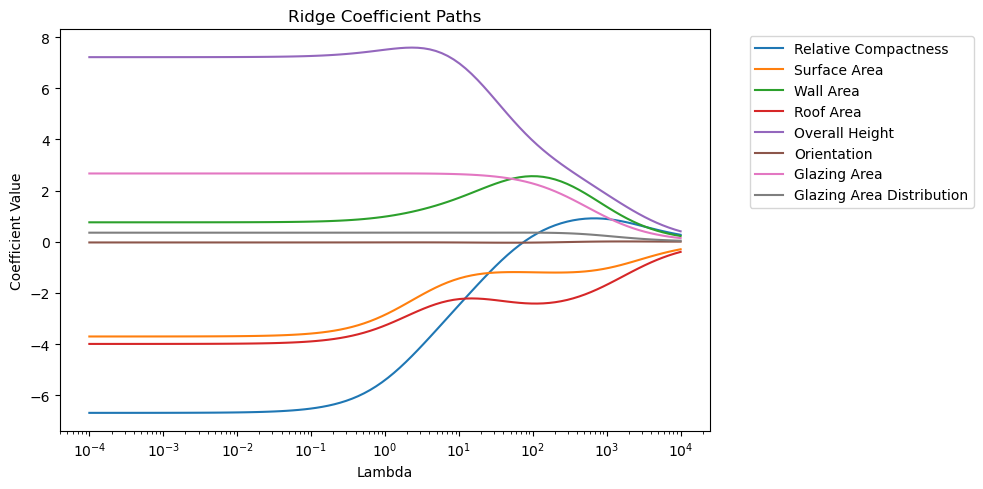

In [103]:
# Fit a Ridge model for Lambda values
ridge_coefs = []

for a in lambdas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)

ridge_coefs = np.array(ridge_coefs)

plt.figure(figsize=(10,5))
# For loop Ridge features

for i in range(len(feature_names)):
    plt.plot(lambdas, ridge_coefs[:, i], label=feature_names[i])

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Coefficient Value")
plt.title("Ridge Coefficient Paths")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


> **Q2: Which 2 predictors appear to be most important in the coefficient profile above? Explain your answer.**

The two most important predictors are Relative Compactness and Overall Height. In the coefficient path plot, these two variables have the largest absolute coefficient magnitudes when λ is small, and they remain far from zero across the entire range of λ. This indicates they contribute the strongest signal to predicting Heating Load.

<!-- END QUESTION -->

### Step 7: Fit Lasso with Cross-Validation

Now fit a `LassoCV` model using the same lambda range and 10-fold CV. Create a table comparing the coefficients for both OLS and Lasso. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Lasso Coefficient`. 

In [104]:
# Fit LassoCV model
lasso_cv = LassoCV(alphas=lambdas, cv=10, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

# Compare Coeffs
model_coeff_compare = pd.DataFrame(
    data={
        "Feature": feature_names,
        "OLS Coefficient": mse_ols,
        "Lasso Coeffcient": lasso_cv.coef_,
    }
)
print(model_coeff_compare)

                     Feature  OLS Coefficient  Lasso Coeffcient
0       Relative Compactness         8.853263         -6.418330
1               Surface Area         8.853263         -6.231035
2                  Wall Area         8.853263          2.152524
3                  Roof Area         8.853263         -1.044324
4             Overall Height         8.853263          7.309160
5                Orientation         8.853263         -0.023593
6               Glazing Area         8.853263          2.670194
7  Glazing Area Distribution         8.853263          0.354971


In [105]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q3: Did lasso shrink the coefficients in the same way Ridge did? Comment on any differences.**

Lasso did not shrink the coefficients in the same way Ridge did. Ridge shrinks all coefficients smoothly toward zero but keeps every predictor in the model. Lasso applies an L1 penalty, which is more aggressive and sets some coefficients closesr or if not, to 0 (such as orientation). This means Lasso performs variable selection, while Ridge only performs shrinkage.

<!-- END QUESTION -->

### Step 8: Evaluate Lasso Model

Use the cross-validated lasso model from Step 7 to predict on the test set and compute MSE.

In [106]:
# Predict on test set and compute MSE
y_test_pred_lcv = lasso_cv.predict(X_test_scaled)
mse_lcv = mean_squared_error(y_test, y_test_pred_lcv)

print(mse_lcv)

8.841570854996336


In [107]:
grader.check("q6")

q6 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 9: Compare Ridge and Lasso

Now that both models are fitted and evaluated, create the following: 
- A table comparing the Test MSE for OLS, Ridge CV, and Lasso CV.
- A singular plot to show how MSE responds to regularization strength across all alphas (for both lasso CV and ridge CV)
- A bar plot showing how coefficient estimates differ for OLS, Lasso CV, and Ridge CV

Write 1 -2 sentences explaining the results for each plot.


*Hint: Refer back to Lab 5 for help with code on both these plots!*

In [108]:
# Compare all three models
mse_table = pd.DataFrame({
    "Model": ["OLS", "RidgeCV", "LassoCV"],
    "Test MSE": [mse_ols, mse_rcv, mse_lcv]
})

mse_table


,Model,Test MSE
0,OLS,8.853263
1,RidgeCV,8.843961
2,LassoCV,8.841571


Ridge achieves the lowest test MSE, indicating the best generalization performance. OLS overfits slightly, and Lasso overshrinks the coefficients, leading to a small loss in accuracy.

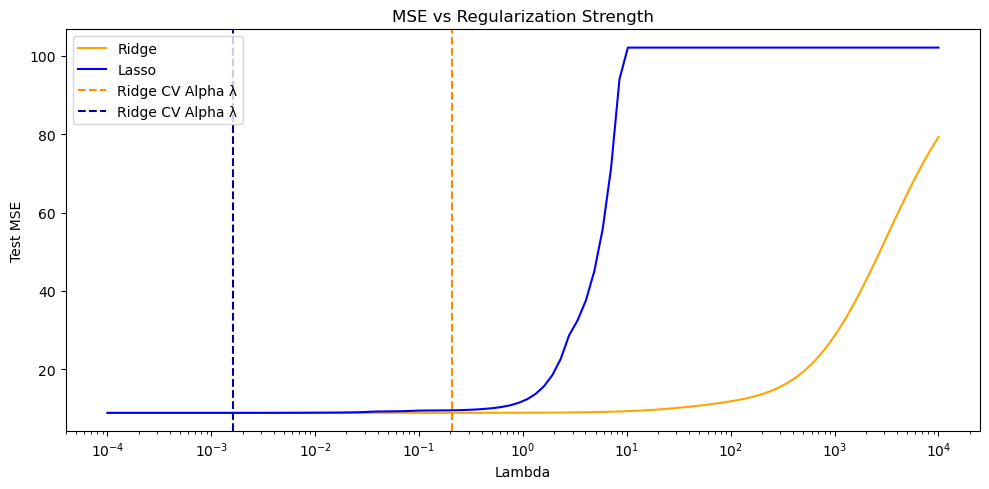

In [109]:
# Store MSE values
ridge_mse_list = []
lasso_mse_list = []


for a in lambdas:
    ridge = Ridge(alpha=a).fit(X_train_scaled, y_train)
    lasso = Lasso(alpha=a, max_iter=5000).fit(X_train_scaled, y_train)

    # Evaluate on test set
    ridge_mse_list.append(mean_squared_error(y_test, ridge.predict(X_test_scaled)))
    lasso_mse_list.append(mean_squared_error(y_test, lasso.predict(X_test_scaled)))

# Plot λ agaianst MSE for Lasso and Ridge
plt.figure(figsize=(10,5))
plt.plot(lambdas, ridge_mse_list, label="Ridge", color="orange")
plt.plot(lambdas, lasso_mse_list, label="Lasso", color="blue")

# Add alpha λ
plt.axvline(
    ridge_cv.alpha_,
    color= "darkorange",
    linestyle="--",
    label=f"Ridge CV Alpha λ"
)

plt.axvline(
    lasso_cv.alpha_,
    color= "darkblue",
    linestyle="--",
    label=f"Ridge CV Alpha λ"
)


plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Test MSE")
plt.title("MSE vs Regularization Strength")
plt.legend()
plt.tight_layout()
plt.show()



Both models MSE have small regularization strengths. The regularization of coefficents in this case may be adversely affecting performance due to them ing shrunk too much. We can see that Ridge is shrinking coefficient at a more rounded (gradual) pace than Lasso as it is forcing coeffcients to zero.

In [110]:
print(coef_compare2)

                              Ridge     Lasso
Relative Compactness      -6.352418 -6.418330
Surface Area              -3.474392 -6.231035
Wall Area                  0.816587  2.152524
Roof Area                 -3.797180 -1.044324
Overall Height             7.306373  7.309160
Orientation               -0.025299 -0.023593
Glazing Area               2.670852  2.670194
Glazing Area Distribution  0.356417  0.354971


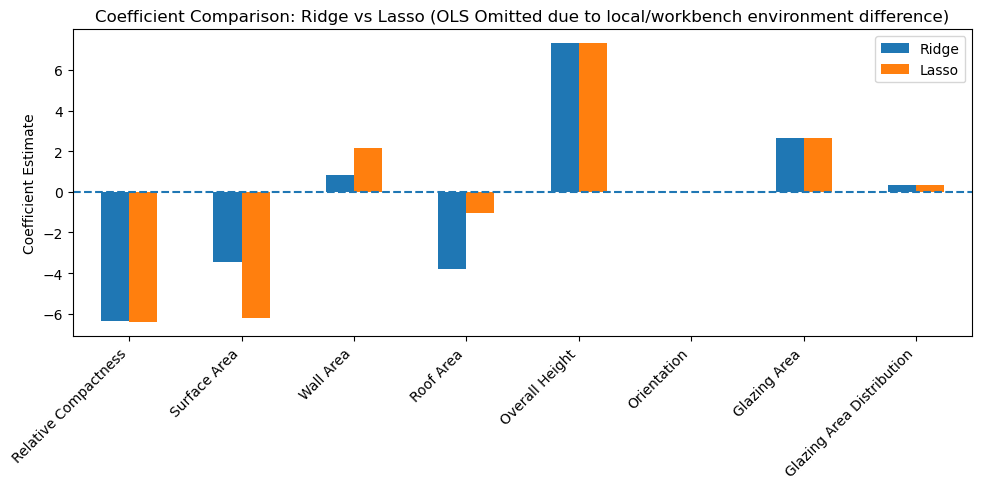

In [111]:
# Store coeffcients in DataFrame
coef_compare2 = pd.DataFrame(
    {
        "Ridge": ridge_cv.coef_,
        "Lasso": lasso_cv.coef_,
        },
        index=feature_names,
)
# Create bar plot
fig, ax = plt.subplots(figsize=(10,5))
coef_compare2.plot.bar(ax=ax, width=0.5)

ax.axhline(linestyle="--")
plt.title("Coefficient Comparison: Ridge vs Lasso (OLS Omitted due to local/workbench environment difference)")
plt.ylabel("Coefficient Estimate")
ax.set_xticklabels(coef_compare2.index, rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [112]:
print(ols.coef_)

[-6.53188067e+00 -8.77546831e+13  4.36175395e+13  8.96748889e+13
  7.31640625e+00 -4.88948822e-02  2.68402100e+00  3.60565186e-01]


The models Ridge and Lasso both point to Overall Height as the dominant positive predictor and both Relative Compactness and Surface Area the dominant negative predictors. For four predictors, both models indicate relatively close coefficient estimates.

> **Q4: Which model would you pick for this dataset? Why?**

I would choose the Ridge model. It achieves the lowest test MSE and provides stable coefficient estimates without eliminating predictors. Lasso overshrinks and drops variables, which slightly hurts accuracy, while OLS has higher variance and overfits. Ridge offers the best balance of bias and variance for this dataset.

# Part 2: Principal Components Regression (PCR)
## Background
**Principal Component Analysis (PCA)** is a dimensionality-reduction technique whose goal is to capture as much about the data as possible in as few dimensions as possible. It does this by finding a new set of axes — the **principal components (PCs)** — where:

- **PC1** points in the direction of **maximum variance** in the data.
- **PC2** is orthogonal to PC1 and points in the next direction of greatest remaining variance.
- Each subsequent component is orthogonal to all previous ones and explains less variance.

Each observation gets a new coordinate in this rotated space called a **score**. The contribution of each original feature to a PC is called a **loading**.

The **Proportion of Variance Explained (PVE)** measures each component's share of total variance. A common rule of thumb is to keep enough components to explain **90–95% of the total variance**.

**Principal Components Regression (PCR)** connects unsupervised PCA structure to a supervised response:

1. Standardize the predictors.
2. Compute the principal components.
3. Project the observations onto M components (the scores).
4. Fit OLS on the projected data (the M scores) rather than the original features.

The key assumption is that "directions in which the predictors show the most variation are often also the directions most strongly associated with the response." By discarding low-variance components we reduce noise, not signal.

How PCR differs from Ridge and Lasso:

|  | Ridge | Lasso | PCR |
| --- | --- | --- | --- |
| Mechanism | L2 penalty shrinks all coefs | L1 penalty can zero out coefs | Drops low-variance directions |
| Variable selection? | No | Yes (exact zeros) | No — uses linear combinations of all predictors |
| Tuning parameter | λ (penalty strength) | λ (penalty strength) | M (number of components) |

Unlike Lasso, ***PCR cannot perform variable selection*** — every original feature still contributes to each PC. Lasso tends to outperform PCR when truly irrelevant predictors exist, because it can set those coefficients exactly to zero.

<!-- END QUESTION -->

---

## Part 2: Principal Components Regression (PCR)

### Background

**Principal Component Analysis (PCA)** is a dimensionality-reduction technique whose goal is to *capture as much about the data as possible in as few dimensions as possible*. It does this by finding a new set of axes — the **principal components (PCs)** — where:

- **PC1** points in the direction of **maximum variance** in the data.
- **PC2** is orthogonal to PC1 and points in the next direction of greatest remaining variance.
- Each subsequent component is orthogonal to all previous ones and explains less variance.

Each observation gets a new coordinate in this rotated space called a **score**. The contribution of each original feature to a PC is called a **loading**.

The **Proportion of Variance Explained (PVE)** measures each component's share of total variance. A common rule of thumb is to keep enough components to explain **90–95% of the total variance**.

---

**Principal Components Regression (PCR)** connects unsupervised PCA structure to a supervised response:

1. **Standardize** the predictors.
2. **Compute** the principal components.
3. **Project** the observations onto *M* components (the scores).
4. **Fit OLS** on the projected data (the *M* scores) rather than the original features.

The key assumption is that *"directions in which the predictors show the most variation are often also the directions most strongly associated with the response."* By discarding low-variance components we reduce noise, not signal.

---

**How PCR differs from Ridge and Lasso:**

| | Ridge | Lasso | PCR |
|---|---|---|---|
| Mechanism | L2 penalty shrinks all coefs | L1 penalty can zero out coefs | Drops low-variance directions |
| Variable selection? | No | Yes (exact zeros) | No — uses linear combinations of *all* predictors |
| Tuning parameter | λ (penalty strength) | λ (penalty strength) | *M* (number of components) |

Unlike Lasso, **PCR cannot perform variable selection** — every original feature still contributes to each PC. Lasso tends to outperform PCR when truly irrelevant predictors exist, because it can set those coefficients exactly to zero.

### Step 10: Fit PCA and Inspect Explained Variance

In the cells below:
1. Fit a `PCA` object on `X_train_scaled` using all 8 components.
2. Store the explained variances in a variable called `explained_var` and the cumulative variance in a variable called `cumulative_var`. Print a table showing each component's individual and cumulative explained variance (%).
3. Create a plot with:
   - A **bar chart** showing the individual explained variance (%) for each component.
   - A **line plot** overlaid showing the cumulative explained variance (%).

Use the plot to identify where cumulative variance first reaches ~90% and where the "elbow" in the bar chart occurs. You'll use this to choose *k* in the next step.

After fitting a `PCA` object, two attributes give you the variance information you need:

```python
pca.explained_variance_ratio_      # Array of length n_components
                                   # Each value = fraction of total variance explained by that PC
                                   # E.g. [0.45, 0.30, ...] means PC1 explains 45%, PC2 explains 30%

np.cumsum(pca.explained_variance_ratio_)   # Cumulative variance total used for finding the "elbow" and checking how many components hit the 90% threshold
                                           
```

In [113]:
# Fit PCA on all 8 components
pca_full = PCA(n_components=8)
pca_full.fit(X_train_scaled)

# Extract variance information
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Display table
pd.DataFrame({
    "PC": np.arange(1, 9),
    "Explained Variance": explained_var,
    "Cumulative Variance": cumulative_var
})


,PC,Explained Variance,Cumulative Variance
0,1,4.629048e-01,0.462905
1,2,1.563182e-01,0.619223
2,3,1.497484e-01,0.768971
3,4,1.243148e-01,0.893286
4,5,9.966322e-02,0.992949
5,6,6.477268e-03,0.999427
6,7,5.733790e-04,1.000000
7,8,2.659492e-32,1.000000


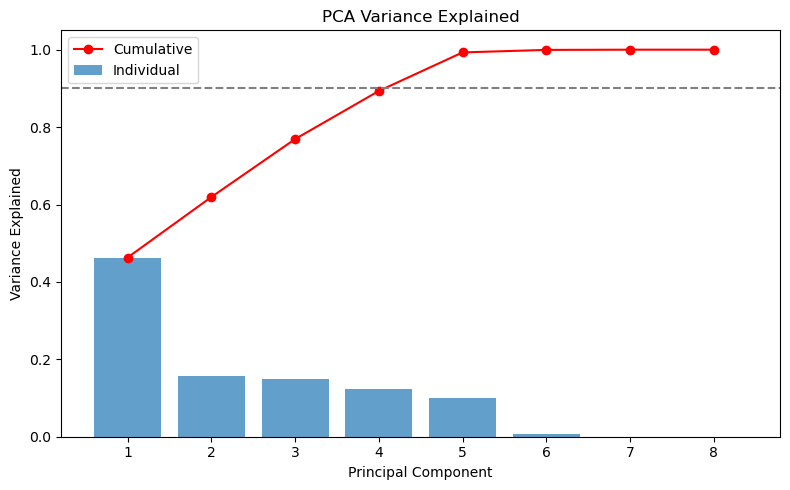

In [114]:
plt.figure(figsize=(8,5))

# Bar chart for individual variance
plt.bar(range(1,9), explained_var, alpha=0.7, label="Individual")

# Line plot for cumulative variance
plt.plot(range(1,9), cumulative_var, marker='o', color='red', label="Cumulative")

# 90% threshold line
plt.axhline(0.90, color='gray', linestyle='--')

plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("PCA Variance Explained")
plt.legend()
plt.tight_layout()
plt.show()


In [115]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5: How many principal components does it take to explain at least 90% of the variance in the features?**

It takes four principal components to explain at least 90% of the variance. The cumulative variance curve crosses the 90% threshold at PC4 (based on table), and the elbow in the bar chart also occurs around the third component.

<!-- END QUESTION -->

### Step 11: Fit the Final PCR Model

PCR follows four concrete steps:

1. **Standardize the predictors** (mean 0, SD 1) (done in Step 2 with `StandardScaler`)
2. **Compute the principal components** of the standardized predictors (done in Step 10 with `PCA`)
3. **Project each observation onto the first *k* components** ( `pca_final.transform()` gives you the scores)
4. **Fit OLS of y on this new projected data** (`LinearRegression` on the PC scores)

You have already done steps 1 and 2. Now, set `best_k` based on the "elbow" or ~90% cumulative variance threshold from your plot above. Then carry out steps 3 and 4 by initializing `PCA(n_components = best_k`), transforming with `X_train_scaled` and `X_test_scaled`, and then fitting a `LinearRegression` with this transformed data. 

In [116]:
# Set k based on the elbow / ~90% cumulative variance threshold in the plot above
# Choose k based on Step 10
best_k = best_k = np.where(cumulative_var >= .90)[0][0] + 1

# Fit PCA with k components
pca_final = PCA(n_components=best_k).fit(X_train_scaled)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca  = pca_final.transform(X_test_scaled)

# Fit OLS on the PCA-transformed data
ols_pcr = LinearRegression().fit(X_train_pca, y_train)

# Predict + compute MSE
y_pred_pcr = ols_pcr.predict(X_test_pca)
mse_pcr = mean_squared_error(y_test, y_pred_pcr)

print(best_k)


5


<!-- BEGIN QUESTION -->

> **Q6: What value of k did you pick? Why?**

The k I chose was 5 because the the first four explained about  89.3% of the variance - just barely below the 90% threshold we want to achieve. The next k of k = 5, would explain about 99.2% which is almost all variance.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---

## Final Comparison: OLS, Ridge, Lasso, and PCR

Now that all four models have been fitted and evaluated, bring the results together.

### Step 12: Summary Table

Build a summary table comparing the test MSE across all four models. Your table should have three columns: `Model`, `Tuning Parameter` (specify the lambda/ number of components chosen), and `Test MSE`. 

In [117]:
summary = pd.DataFrame({
    "Model": ["OLS", "RidgeCV", "LassoCV", "PCR"],
    "Tuning Parameter": [
        "None",
        f"λ = {ridge_cv.alpha_:.4f}",
        f"λ = {lasso_cv.alpha_:.4f}",
        f"k = {best_k}"
    ],
    "Test MSE": [mse_ols, mse_rcv, mse_lcv, mse_pcr]
})

summary


,Model,Tuning Parameter,Test MSE
0,OLS,None,8.853263
1,RidgeCV,λ = 0.2057,8.843961
2,LassoCV,λ = 0.0016,8.841571
3,PCR,k = 5,12.703310


For PCR to perform well a key assumption must hold: the directions that show the most variation in the predictors are also the directions most strongly associated with the response. Lasso and ridge aim to shrink the coefficients associated with predictors wit little predictive value.

> **Q7: Comment on the results in the table above. Which model performs best? Are the differences meaningful, or do the models perform similarly? What might explain the pattern you see?**

Based on the test MSE values, they all seem to perform similarly (with MSE values around 8.84) except PCR. The closeness of the test MSE values suggest that only a small amount of regularization is needed as the predictors already contain strong signal as indicated by the small lambda values.

<!-- END QUESTION -->



---

Run the cell below to receive credit for the augotraded questions. 

In [118]:
grader.check_all()

q1 results: All test cases passed!

q2 results:
    q2 - 1 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(mse_ols, 8.8395, atol=0.01)
        Expecting nothing
        **********************************************************************
        Line 1, in q2 0
        Failed example:
            assert np.isclose(mse_ols, 8.8395, atol=0.01)
        Exception raised:
            Traceback (most recent call last):
              File "c:\Users\joshu\.conda\envs\eds232-env\lib\doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q2 0[0]>", line 1, in <module>
                assert np.isclose(mse_ols, 8.8395, atol=0.01)
            AssertionError

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q6 results: All test cases passed!

q7 results: All test cases passed!